# ** The hardware experiments from this notebook failed **

In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager
from qiskit.providers.backend import BackendV2 as Backend
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, ASAPScheduleAnalysis
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate 
from qiskit.quantum_info import hellinger_fidelity
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
from qiskit.transpiler.passes import BasisTranslator
 


In [2]:
def prepare_echo_ghz_with_xs(n_qubits:int):
    ## Prepares echo circuit with for ghz circuit. Xs at the end to make the expectation value 1. 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.barrier()

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.barrier()

    circuit.x(range(n_qubits))

    circuit.measure_all()

    return circuit


def naked_sampler(mode, shots=4096):
    ## Sampler with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    options = SamplerOptions(default_shots=shots, dynamical_decoupling={"enable": False}, twirling={"enable_gates": False, "enable_measure": False})
    sampler = Sampler(mode=mode, options=options)
    return sampler

# Changing the PM with schedueling included
def pm_for_backend(bknd, opt_level, seed=42069, schedueling_method="alap"):
    ## Returns a PassManager from generate_preset_pass_manager for given opt_level and backend(bknd)
    pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed, scheduling_method="alap")
    return pm


def prepare_dd_pm(backend:Backend, scheduling_method="alap", seq=[XGate(), XGate()]):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 
    
    target = backend.target
    ## Prepare a preset passmanager for backend optimization_level=3
    pm = pm_for_backend(bknd=backend, opt_level=3, seed=42069, schedueling_method=scheduling_method)
    pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=seq))
        
    return pm




def execute_on_hardware(bknd, sampler_pub):
    ## Batch mode execution of quantum circuits on hardware
    with Batch(backend=bknd) as batch:
        sampler = naked_sampler(mode=batch, shots=4096)
        job = sampler.run(sampler_pub)
        id = job.job_id()
        print(id)
    return id


def get_result_from_id(service, id):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def get_fidelity_for_circuit(ideal=dict, simulated=dict, no_dd_counts=dict, dd_counts=dict):

    ## Returns List[List] of hellinger fidelity results. Outer list is of length 2 and contains
    # 0 :- List of len 3 with hellinger fidelity compared to ideal counts. [hellinger_simulated, hellinger_no_dd, hellinger_dd]
    # 1 :- List of len 2 with hellinger fidelity compared to simulated counts. [hellinger_no_dd, hellinger_dd]

    # Calculating hellinger fidelity compared to ideal counts

    hellinger_results = []

    for target_result in [simulated, no_dd_counts, dd_counts]:

        hellinger_results.append(hellinger_fidelity(ideal, target_result))

    # Calculate hellinger fidelity compared to simulated counts

    alt_hellinger_results = []

    for target_result in [no_dd_counts, dd_counts]:
        alt_hellinger_results.append(hellinger_fidelity(simulated, target_result))



    return [hellinger_results, alt_hellinger_results]

In [3]:
test7 = prepare_echo_ghz_with_xs(7)
test7.draw(fold=-1)

┌───┐                               ░  ░                               ┌───┐ ░ ┌───┐ ░ ┌─┐                  
   q_0: ┤ H ├──■────────────────────────────░──░────────────────────────────■──┤ H ├─░─┤ X ├─░─┤M├──────────────────
        └───┘┌─┴─┐                          ░  ░                          ┌─┴─┐└───┘ ░ ├───┤ ░ └╥┘┌─┐               
   q_1: ─────┤ X ├──■───────────────────────░──░───────────────────────■──┤ X ├──────░─┤ X ├─░──╫─┤M├───────────────
             └───┘┌─┴─┐                     ░  ░                     ┌─┴─┐└───┘      ░ ├───┤ ░  ║ └╥┘┌─┐            
   q_2: ──────────┤ X ├──■──────────────────░──░──────────────────■──┤ X ├───────────░─┤ X ├─░──╫──╫─┤M├────────────
                  └───┘┌─┴─┐                ░  ░                ┌─┴─┐└───┘           ░ ├───┤ ░  ║  ║ └╥┘┌─┐         
   q_3: ───────────────┤ X ├──■─────────────░──░─────────────■──┤ X ├────────────────░─┤ X ├─░──╫──╫──╫─┤M├─────────
                       └───┘┌─┴─┐           ░  ░           ┌─┴─┐└───┘                ░ ├───┤ ░  ║  ║  ║ └╥┘┌─┐      
   q_4: ────────────────────┤ X ├──■────────░──░────────■──┤ X ├─────────────────────░─┤ X ├─░──╫──╫──╫──╫─┤M├──────
                            └───┘┌─┴─┐      ░  ░      ┌─┴─┐└───┘                     ░ ├───┤ ░  ║  ║  ║  ║ └╥┘┌─┐   
   q_5: ─────────────────────────┤ X ├──■───░──░───■──┤ X ├──────────────────────────░─┤ X ├─░──╫──╫──╫──╫──╫─┤M├───
                                 └───┘┌─┴─┐ ░  ░ ┌─┴─┐└───┘                          ░ ├───┤ ░  ║  ║  ║  ║  ║ └╥┘┌─┐
   q_6: ──────────────────────────────┤ X ├─░──░─┤ X ├───────────────────────────────░─┤ X ├─░──╫──╫──╫──╫──╫──╫─┤M├
                                      └───┘ ░  ░ └───┘                               ░ └───┘ ░  ║  ║  ║  ║  ║  ║ └╥┘
meas: 7/════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩══╩══╩═
                                                                                                0  1  2  3  4  5  6

In [4]:
service = QiskitRuntimeService(name="qamp-2025")


management.get:WARNING:2025-11-28 02:17:06,310: Loading saved account: qamp-2025


In [5]:
marrakesh = service.backend("ibm_marrakesh")

In [6]:
marrakesh

<IBMBackend('ibm_marrakesh')>

In [7]:

def summarize_backend(backend):
    """Return a structured snapshot of backend properties for an online IBMBackend."""
    try:
        config = backend.configuration()
    except Exception:
        config = None

    try:
        props = backend.properties()
    except Exception:
        props = None

    num_qubits = getattr(backend, "num_qubits", None)
    if callable(num_qubits):
        num_qubits = num_qubits()

    dt = None
    if config and hasattr(config, "dt"):
        dt = getattr(config, "dt", None)
    elif getattr(backend, "dt", None):
        dt = backend.dt
    elif getattr(getattr(backend, "target", None), "dt", None):
        dt = backend.target.dt

    granularity = None
    if config and getattr(config, "timing_constraints", None):
        granularity = config.timing_constraints.get("granularity")
    if granularity is None and getattr(getattr(backend, "target", None), "granularity", None):
        granularity = backend.target.granularity

    summary = {
        "backend_name": getattr(backend, "name", lambda: str(backend))(),
        "num_qubits": num_qubits or (getattr(config, "num_qubits", None) if config else None),
        "basis_gates": [],
        "supported_instructions": [],
        "coupling_map": None,
        "qubit_properties": [],
        "gate_parameters": [],
        "last_update": None,
        "dt": dt,
        "granularity": granularity,
    }

    target = getattr(backend, "target", None)
    if config and getattr(config, "basis_gates", None):
        summary["basis_gates"] = list(config.basis_gates)
    elif target is not None:
        summary["basis_gates"] = sorted(list(target.operations))

    if target is not None:
        summary["supported_instructions"] = sorted(list(target.operations))

    coupling_map = None
    if config and getattr(config, "coupling_map", None):
        coupling_map = [list(edge) for edge in config.coupling_map]
    elif getattr(backend, "coupling_map", None):
        cm = backend.coupling_map
        if cm:
            coupling_map = [list(edge) for edge in cm]
    elif target is not None:
        try:
            target_map = target.build_coupling_map()
            if target_map:
                coupling_map = [list(edge) for edge in target_map.get_edges()]
        except Exception:
            pass
    summary["coupling_map"] = coupling_map

    if props:
        props_dict = props.to_dict()
        for qubit_index, qubit_props in enumerate(props_dict.get("qubits", [])):
            values = {entry["name"]: entry["value"] for entry in qubit_props}
            readout_error = values.get("readout_error")
            if readout_error is None and {"prob_meas0_prep1", "prob_meas1_prep0"}.issubset(values):
                readout_error = (values["prob_meas0_prep1"] + values["prob_meas1_prep0"]) / 2

            summary["qubit_properties"].append({
                "qubit": qubit_index,
                "t1": values.get("T1"),
                "t2": values.get("T2"),
                "frequency": values.get("frequency"),
                "readout_error": readout_error,
            })

        for gate in props_dict.get("gates", []):
            params = {param["name"]: param["value"] for param in gate.get("parameters", [])}
            summary["gate_parameters"].append({
                "gate": gate.get("gate"),
                "qubits": gate.get("qubits"),
                "gate_error": params.get("gate_error"),
                "gate_length": params.get("gate_length"),
            })

        summary["last_update"] = props_dict.get("last_update_date")

    return summary




def build_dd_pass_manager(backend, sequence="XX", scheduling_method="alap", opt_level=3, seed=42069):
    """Create a PassManager that inserts a chosen DD sequence (XX, XpXm, or XY)."""
    from qiskit.circuit.library import XGate, YGate

    seq_key = sequence.lower()
    dd_sequences = {
        "xx": [XGate(), XGate()],
        "xpxm": [XGate(), XGate().inverse()],
        "xy": [XGate(), YGate(), XGate(), YGate()],
    }
    if seq_key not in dd_sequences:
        raise ValueError(f"Unsupported DD sequence '{sequence}'. Choose from XX, XpXm, XY.")

    target = backend.target

    basis_gates = list(backend.target.operations)
    print(basis_gates)

    if seq_key == "xy":
        from qiskit.transpiler import InstructionProperties
 
        y_gate_properties = {}
        for qubit in range(target.num_qubits):
            y_gate_properties.update(
                {
                    (qubit,): InstructionProperties(
                        duration=target["x"][(qubit,)].duration,
                        error=target["x"][(qubit,)].error,
                    )
                }
            )
        
        target.add_instruction(YGate(), y_gate_properties)
    
    pm = generate_preset_pass_manager(
        optimization_level=opt_level,
        backend=backend,
        seed_transpiler=seed,
        scheduling_method=scheduling_method,
    )

    schedule_pass = ALAPScheduleAnalysis if scheduling_method == "alap" else ASAPScheduleAnalysis
    pm.scheduling.append(schedule_pass(target=target))
    pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=dd_sequences[seq_key]))

    return pm




def transpile_for_dd(circuit, backend, dd_seq:str = "XX", scheduling_method:str = "alap", opt_level:int = 3, seed:int = 42069):
    dd_pm = build_dd_pass_manager(backend, sequence=dd_seq, scheduling_method=scheduling_method, opt_level=opt_level, seed=seed)
    dd_circuit = dd_pm.run(circuit)

    target = backend.target
    basis_gates = list(target.operation_names)
    
    
    isa_dd_circuit = BasisTranslator(sel, basis_gates)(dd_circuit)

    return isa_dd_circuit
    



In [8]:
pm3 = pm_for_backend(marrakesh, opt_level=3, seed=42069)

isa_dd_xy = transpile_for_dd(test7, marrakesh, "XY", scheduling_method='alap', opt_level=3, seed=42069)

isa_dd_xx = transpile_for_dd(test7, marrakesh, "XX", scheduling_method='alap', opt_level=3, seed=42069)

isa_dd_xpxm = transpile_for_dd(test7, marrakesh, "XpXm", scheduling_method='alap', opt_level=3, seed=42069)



isa_dict = {}
isa_dict["no_dd"] = pm3.run(test7)
isa_dict["xx"]    = isa_dd_xx
isa_dict["xpxm"]  = isa_dd_xpxm
isa_dict["xy"]    = isa_dd_xy

[Delay(duration=t[unit=dt]), Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), <class 'qiskit.circuit.controlflow.if_else.IfElseOp'>, Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]), Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]), Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]), Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), Instruction(name='sx', num_qubits=1, num_clbits=0, params=[])]
[Delay(duration=t[unit=dt]), Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), <class 'qiskit.circuit.controlflow.if_else.IfElseOp'>, Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]), Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]), Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]), Instruction(name='x', num_qubits=1, n

In [12]:
isa_dict["no_dd"].draw(idle_wires=False, fold=-1)

global phase: π/2
             ┌─────────┐       ┌────┐  ┌─────────┐         ┌────────────────┐                                                                                                                                                                       ░  ░ ┌────────────────┐                                                                                                                                                                                                             ┌─────────┐   ┌────┐  ┌─────────┐ ░ ┌───┐ ░ ┌─┐                  
 q_0 -> 6 ───┤ Rz(π/2) ├───────┤ √X ├──┤ Rz(π/2) ├────■────┤ Delay(142[dt]) ├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──░─┤ Delay(142[dt]) ├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π/2) ├─░─┤ X ├─░─┤M├──────────────────
             ├─────────┤       ├────┤  └┬───────┬┘    │    └─────┬────┬─────┘┌─────────┐   ┌────────────────┐                                                                                                                                       ░  ░ ├────────────────┤                                                                                                                                                                           ┌─────────┐   ┌────┐ ┌───────┐  │ └──┬────┬─┘┌──┴────┴─┐└─────────┘ ░ ├───┤ ░ └╥┘┌─┐               
 q_1 -> 7 ───┤ Rz(π/2) ├───────┤ √X ├───┤ Rz(π) ├─────■──────────┤ √X ├──────┤ Rz(π/2) ├─■─┤ Delay(113[dt]) ├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──░─┤ Delay(113[dt]) ├──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■────┤ Rz(π/2) ├───┤ √X ├─┤ Rz(π) ├──■────┤ √X ├──┤ Rz(π/2) ├────────────░─┤ X ├─░──╫─┤M├───────────────
          ┌──┴─────────┴──┐ ┌──┴────┴─┐ └─┬────┬┘ ┌───────┐      └────┘      └─────────┘ │ └─────┬────┬─────┘┌─────────┐   ┌───────────────┐                                                                                                        ░  ░ ├───────────────┬┘                                                                                                                                      ┌─────────┐   ┌────┐ ┌───────┐  │ ┌──┴─────────┴──┐├────┤┌┴───────┴┐      └────┘  └─────────┘            ░ ├───┤ ░  ║ └╥┘┌─┐            
 q_2 -> 8 ┤ Delay(26[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├──────────────────────────────■───────┤ √X ├──────┤ Rz(π/2) ├─■─┤ Delay(87[dt]) ├────────────────────────────────────────────────────────────────────────────────────────────────────────░──░─┤ Delay(87[dt]) ├──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■────┤ Rz(π/2) ├───┤ √X ├─┤ Rz(π) ├──■─┤ Delay(26[dt]) ├┤ √X ├┤ Rz(π/2) ├─────────────────────────────────────░─┤ X ├─░──╫──╫─┤M├────────────
          ├───────────────┤ ├─────────┤   ├────┤  ├───────┤                                      └────┘      └─────────┘ │ └─────┬────┬────┘┌─────────┐   ┌───────────────┐                                                                         ░  ░ ├───────────────┤                                                                                                  ┌─────────┐   ┌────┐ ┌───────┐  │ ┌──┴─────────┴──┐├────┤┌┴───────┴┐   └───────────────┘└────┘└─────────┘                                     ░ ├───┤ ░  ║  ║ └╥┘┌─┐         
 q_3 -> 9 ┤ Delay(55[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├──────────────────────────────────────────────────────────────■───────┤ √X ├─────┤ Rz(π/2) ├─■─┤ Delay(61[dt]) ├─────────────────────────────────────────────

In [11]:
isa_dict["xy"].draw(idle_wires=False, fold=-1)

global phase: π/2
           ┌─────────┐       ┌────┐  ┌─────────┐         ┌───────────────┐   ┌───┐   ┌───────────────┐     ┌───┐      ┌───────────────┐      ┌───┐      ┌───────────────┐      ┌───┐      ┌───────────────┐                                                                                                                                               ░  ░ ┌───────────────┐┌───┐ ┌───────────────┐┌───┐┌───────────────┐┌───┐ ┌───────────────┐┌───┐┌───────────────┐                                                                                                                                                                    ┌─────────┐      ┌────┐  ┌─────────┐ ░ ┌───┐ ░ ┌─┐                  
   q_6: ───┤ Rz(π/2) ├───────┤ √X ├──┤ Rz(π/2) ├────■────┤ Delay(13[dt]) ├───┤ X ├───┤ Delay(26[dt]) ├─────┤ Y ├──────┤ Delay(28[dt]) ├──────┤ X ├──────┤ Delay(26[dt]) ├──────┤ Y ├──────┤ Delay(13[dt]) ├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──░─┤ Delay(13[dt]) ├┤ X ├─┤ Delay(26[dt]) ├┤ Y ├┤ Delay(28[dt]) ├┤ X ├─┤ Delay(26[dt]) ├┤ Y ├┤ Delay(13[dt]) ├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■────┤ Rz(π/2) ├──────┤ √X ├──┤ Rz(π/2) ├─░─┤ X ├─░─┤M├──────────────────
           ├─────────┤       ├────┤  └┬───────┬┘    │    └─────┬────┬────┘┌──┴───┴──┐└───────────────┘┌────┴───┴─────┐└─────┬───┬─────┘┌─────┴───┴─────┐└─────┬───┬─────┘┌─────┴───┴─────┐└─────┬───┬─────┘┌───────────────┐      ┌───┐      ┌──────────────┐                                                                                             ░  ░ └┬──────────────┤├───┤ ├───────────────┤├───┤├───────────────┤├───┤ ├───────────────┤├───┤└┬──────────────┤                                                                                                                         ┌─────────┐   ┌────┐   ┌───────┐      │    └──┬────┬─┘   ┌──┴────┴─┐└─────────┘ ░ ├───┤ ░ └╥┘┌─┐               
   q_7: ───┤ Rz(π/2) ├───────┤ √X ├───┤ Rz(π) ├─────■──────────┤ √X ├─────┤ Rz(π/2) ├────────■────────┤ Delay(9[dt]) ├──────┤ X ├──────┤ Delay(19[dt]) ├──────┤ Y ├──────┤ Delay(21[dt]) ├──────┤ X ├──────┤ Delay(19[dt]) ├──────┤ Y ├──────┤ Delay(9[dt]) ├─────────────────────────────────────────────────────────────────────────────────────────────░──░──┤ Delay(9[dt]) ├┤ X ├─┤ Delay(19[dt]) ├┤ Y ├┤ Delay(21[dt]) ├┤ X ├─┤ Delay(19[dt]) ├┤ Y ├─┤ Delay(9[dt]) ├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├───┤ Rz(π) ├──────■───────┤ √X ├─────┤ Rz(π/2) ├────────────░─┤ X ├─░──╫─┤M├───────────────
        ┌──┴─────────┴──┐ ┌──┴────┴─┐ └─┬────┬┘ ┌───────┐      └────┘     └─────────┘        │        └────┬────┬────┘   ┌──┴───┴──┐   └───────────────┘ ┌────┴───┴─────┐└─────┬───┬─────┘┌─────┴───┴─────┐└─────┬───┬─────┘┌─────┴───┴─────┐└────┬───┬─────┘┌───────────────┐     ┌───┐      ┌──────────────┐                                            ░  ░  ├──────────────┤├───┤ ├───────────────┤├───┤├───────────────┤├───┤ ├───────────────┤├───┤ ├──────────────┤                                                                            ┌─────────┐   ┌────┐    ┌───────┐      │  ┌──┴─────────┴──┐├────┤  ┌┴───────┴┐             └────┘     └─────────┘            ░ ├───┤ ░  ║ └╥┘┌─┐            
   q_8: ┤ Delay(26[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├────────────────────────────────────■─────────────┤ √X ├────────┤ Rz(π/2) ├───────────■─────────┤ Delay(6[dt]) ├──────┤ X ├──────┤ Delay(12[dt]) ├──────┤ Y ├──────┤ Delay(15[dt]) ├─────┤ X ├──────┤ Delay(12[dt]) ├─────┤ Y ├──────┤ Delay(6[dt]) ├────────────────────────────────────────────░──░──┤ Delay(6[dt]) ├┤ X ├─┤ Delay(12[dt]) ├┤ Y ├┤ Delay(15[dt]) ├┤ X ├─┤ Delay(12[dt]) ├┤ Y ├─┤ Delay(6[dt]) ├─────────────────────────────────────────────────────────────────────

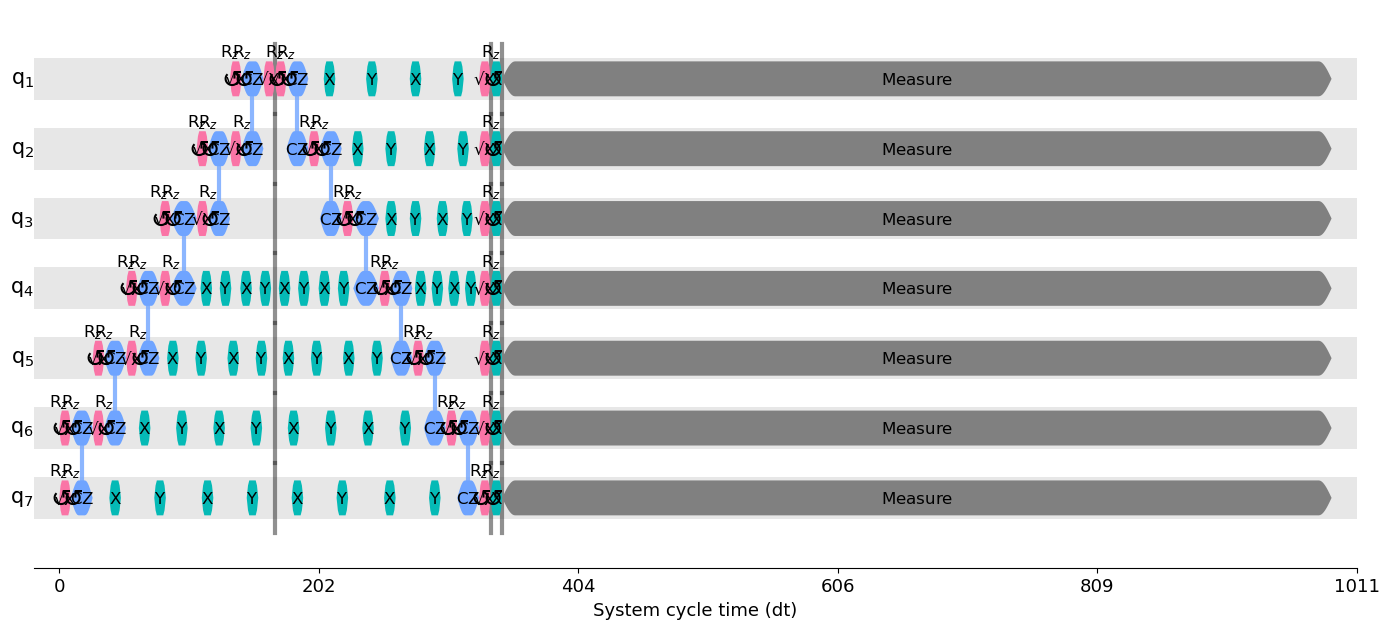

In [12]:
timeline_drawer(isa_dict["xy"], idle_wires=False, target=target)

In [13]:
sample_pub = [(isa_dict["no_dd"]), (isa_dict["xx"]), (isa_dict["xpxm"]), (isa_dict["xy"])]


In [14]:
# job_id = execute_on_hardware(marrakesh, sample_pub)
# job_id

In [15]:
job = service.job("d4h436ulo8as739qa9cg")


In [18]:
from qiskit.transpiler.passes.scheduling import ContextAwareDynamicalDecoupling
def transpile_with_context_aware_dd(
    circuit, backend=None, dd_sequence=None, scheduling_method="alap", opt_level=3, seed=42069
):
    """Transpile with opt_level=3 for ibm_marrakesh and insert ContextAwareDynamicalDecoupling."""
    backend = backend or marrakesh
    dd_sequence = dd_sequence or [XGate(), XGate()]

    target = backend.target
    pm = generate_preset_pass_manager(
        optimization_level=opt_level,
        backend=backend,
        seed_transpiler=seed,
        scheduling_method=scheduling_method,
    )

    schedule_pass = ALAPScheduleAnalysis if scheduling_method == "alap" else ASAPScheduleAnalysis
    pm.scheduling.append(schedule_pass(target=target))
    try:
        cadd_pass = ContextAwareDynamicalDecoupling(target=target)
    except TypeError:
        cadd_pass = ContextAwareDynamicalDecoupling(target=target)
    pm.scheduling.append(cadd_pass)

    return pm.run(circuit)


In [19]:
isa_cadd = transpile_with_context_aware_dd(
    test7, backend=marrakesh, scheduling_method="alap", opt_level=3, seed=42069
)

isa_dict = {}
isa_dict["no_dd"] = pm3.run(test7)
isa_dict["xx"] = isa_dd_xx
isa_dict["xpxm"] = isa_dd_xpxm
isa_dict["xy"] = isa_dd_xy
isa_dict["context_aware_dd"] = isa_cadd

sample_pub = [(isa_dict["no_dd"]), (isa_dict["xx"]), (isa_dict["xpxm"]), (isa_dict["xy"])]


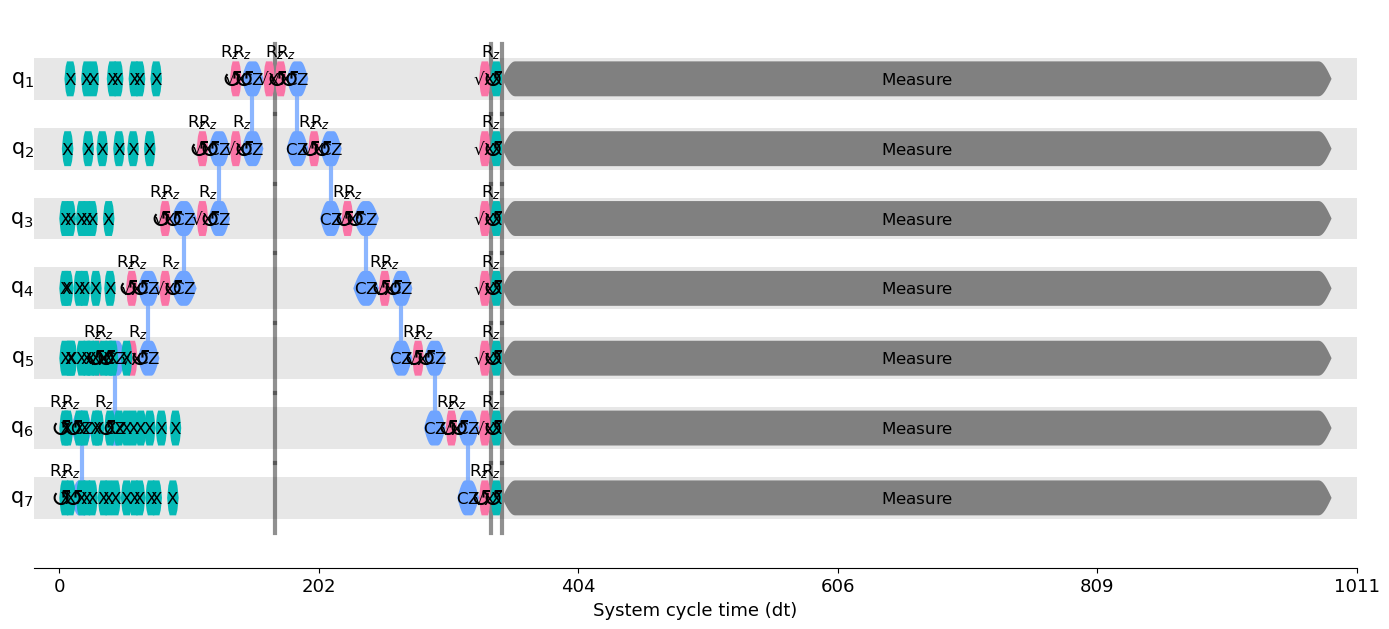

In [20]:
timeline_drawer(isa_dict["context_aware_dd"], idle_wires=False, target=target)

In [ ]:
# job_id_list = []
# for i in range(3):
#     job_id_list.append(execute_on_hardware(marrakesh, sample_pub))

# job_id_list


d4h64k4cdebc73f1oo60
d4h64kglslhc73d1b2j0
d4h64l6lo8as739qc5l0


['d4h64k4cdebc73f1oo60', 'd4h64kglslhc73d1b2j0', 'd4h64l6lo8as739qc5l0']

In [ ]:
job_id_list = ['d4h64k4cdebc73f1oo60', 'd4h64kglslhc73d1b2j0', 'd4h64l6lo8as739qc5l0']